# Forecasting $N_2O$ Concentrations Using LSTM Time Series Multi-Horizon Time Series Forecasting

## Overview

This notebook implements a Long Short-Term Memory (LSTM) model for multi-horizon time series forecasting of $N_2O$ concentrations (mg-N/L) in a wastewater treatment plant (WWTP) bioreactor.

Two complementary models are developed with different target types:

- **Model 1 — Absolute $N_2O$ Forecasting**  
  Predicts future $N_2O$ concentrations directly.

- **Model 2 — Δ$N_2O$ Forecasting**  
  Predicts the rate-of-change in $N_2O$ concentrations.

Both models are trained to predict multiple forecast horizons simultaneously (t+1, t+3, t+6, t+12), allowing assessment of short- to medium-term predictive performance.


#### Modelling Approach

A sequence-based PyTorch deep learning framework is implemented using the LSTM module, which is specifically designed to capture temporal dependencies in time-series data.

Key characteristics of the modelling approach include:

- Use of two historical input sequences (lookback windows): 12 and 24 timesteps (2 and 4 hours respectively)
- Multi-horizon output for simultaneous prediction across future timesteps  
- Training on continuous time-series segments extracted from Segment 4 data to preserve temporal consistency  
- Comparison across feature sets:
  - Baseline features (based on global feature selection)
  - Extended features including dissolved oxygen and phase encodings


#### Model Objectives

The modelling framework is designed to:

- Predict short-term $N_2O$ dynamics and emission peaks  
- Evaluate predictive performance across:
  - Feature sets (baseline vs extended)  
  - Forecast horizons (t+1 → t+12)  
  - Target formulations (absolute $N_2O$ vs Δ$N_2O$)  
- Assess the impact of including or excluding $N_2O$ as an input feature  
- Quantify model capability in detecting high-emission (peak) events  


### Research Focus

This notebook specifically investigates the following questions in alignment with the research objectives defined for our design project:

- How accurately can ML models predict peaks in $N_2O$ concentrations during biological water treatment, and how does model complexity impact predictive accuracy and feasibility? 

- Specifically, how do different modelling approaches (linear regression, random forest, neural networks) compare in terms of predictive performance, interpretability and practical applicability?


#### Modelling Considerations

- Models are trained both **with and without $N_2O$ as an input feature** to assess dependence on autoregressive behaviour 

- Predictive performance is expected to decrease when lagged $N_2O$ is excluded due to strong temporal autocorrelation in alignment with findings from feature enginering

- Multi-horizon forecasting introduces increasing uncertainty with longer prediction windows  

- Segment-based training is used to avoid temporal leakage and ensure physically consistent sequences  


#### Performance Evaluation Metrics

Model performance is evaluated using both regression and event-based metrics:

| Metric | Type | Description | Purpose |
|------|------|------------|--------|
| $R^2$ | Regression | Coefficient of determination | Measures overall goodness-of-fit |
| RMSE | Regression | Root Mean Squared Error | Penalises large prediction errors |
| MAE | Regression | Mean Absolute Error | Measures average prediction deviation |
| Precision | Classification | True positives / predicted positives | Accuracy of predicted peaks |
| Recall | Classification | True positives / actual positives | Ability to detect actual peaks |
| F1 Score | Classification | Harmonic mean of precision and recall | Balanced peak detection performance |

Peak events are defined using the 90th percentile of $N_2O$ concentrations as an extreme-event Nthreshold, enabling evaluation of the model’s ability to identify peaks in the target variable. 

## 1. Upload Data & Configure Environment

### 1.1 Configure Environment 

In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import os

#Visualization libraries
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

#Import file handling and utility libraries
import random 
import datetime
import itertools
import string
import copy 
import joblib

#Sci-kit learn libraries for feature processing 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score

#PyTorch libraries for building and training the LSTM model
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

#For model evaluation
from torchmetrics import MeanSquaredError, R2Score

# TensorBoard for training visualization
from torch.utils.tensorboard import SummaryWriter

# Enable PyTorch MPS fallback for compatibility
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

#Set device for PyTorch (GPU if available, else CPU)
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

#Warning suppression for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Set seed for reproducibility
def set_seed(seed=222):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # deterministic behaviour
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(222)

Device: mps
CUDA available: False
MPS available: True


In [26]:
#Create tensorboard writer for logging training metrics
writer = SummaryWriter(log_dir="../../runs/lstm_n20")  

In [27]:
#Define color palette for visualizations

# Color mapping for numerical features: 
color_map = {

    # Hydraulic / operational (soft blues)
    "inflow": "#3A54E4",        
    "total_airflow": "#5C6EE8", 
    "t1_airflow": "#7FA6F0",    

    # Nitrogen species (soft reds/purples)
    "t1_n2o": "#E63B54",      
    "t1_nh4": "#C94F9D",        
    "t1_no3": "#8666B8", 

    # Process conditions (soft cyan)
    "t1_do": "#67CFF5",     
     
    # Solids (neutral desaturated blue instead of grey)
    "t1_ss": "#8DA0CB",      

    # Temperature (soft orange)
    "t1_temp": "#F2A26B",     

    # Phosphorus (soft green)
    "t1_po4": "#66C18C"        
}

### 1.2 Load Datasets

Two datasets are used (prepared during dedicated feature engineering for LSTM modelling)

- **Baseline dataset**
  - Baseline features including t1_no3, t1_nh4, t1_airflow, t1_po4, inflow and t1_n2o (target)

- **Extended dataset**
  - Includes additional features (DO, phase encodings) and engineered rolling statistics 

In [28]:
#Upload datasets 

data_path = "../../data/lstm_data"

datasets = {
    "baseline": "seg4_baseline_clean.csv",
    "extended": "seg4_extended_clean.csv",
}

loaded_data = {}

#Set index column and parse datetime 
for name, file in datasets.items():
    df = pd.read_csv(
        os.path.join(data_path, file),
        index_col=0,          
        parse_dates=True   
    )
    
    loaded_data[name] = df
    print(f"{name}: {df.shape}")

baseline: (18277, 7)
extended: (18255, 14)


### 1.3 Data Structure Checks 

#### 1.3.1 Check Datetime Index & Temporal Structure

In [29]:
#Check datime index consistency for all datasets 
for name, df in loaded_data.items():
    print(f"{name} index type:", type(df.index))

baseline index type: <class 'pandas.DatetimeIndex'>
extended index type: <class 'pandas.DatetimeIndex'>


In [30]:
#Check chronological order of datetime index for all datasets
for name, df in loaded_data.items():
    print(f"{name} sorted:", df.index.is_monotonic_increasing)

baseline sorted: True
extended sorted: True


#### 1.3.2 Check Columns 

Verify that the correct features are included in both datasets

In [31]:
#Check columns 
for name, df in loaded_data.items():
    print(f"{name} columns:", df.columns.tolist())

baseline columns: ['t1_n2o', 't1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow']
extended columns: ['t1_n2o', 't1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min']


#### 1.3.3 Verify Sampling Frequency 

In [32]:
#Check timeset consistency across datasets 
for name, df in loaded_data.items():
    diffs = df.index.to_series().diff().dropna()
    print(f"\n{name} time step counts:")
    print(diffs.value_counts().head())


baseline time step counts:
time
0 days 00:10:00    18272
0 days 00:50:00        1
0 days 01:30:00        1
0 days 01:10:00        1
0 days 02:10:00        1
Name: count, dtype: int64

extended time step counts:
time
0 days 00:10:00    18247
0 days 01:10:00        2
0 days 00:40:00        2
0 days 01:50:00        1
0 days 01:30:00        1
Name: count, dtype: int64


##### Sampling Frequency

- After resampling, there are small inconsistencies remaining in the data, likely due to preprocessing, feature engineering steps or removal of invalid rows. 

- For LSTMs, the dataset needs to be sampled at regular intervals. To do this, we will identify continuous segments of data within Segment 4, and use each of them to train the model

In [33]:
#Define function to identify continuous segments of data 

#Define dictionaries to store segments 
segments_all = {}
longest_segments = {}

for name, df in loaded_data.items():
    
    print(f"Dataset name: {name}")

    #Compute time differences
    diffs = df.index.to_series().diff()

    #Identify segments
    gap_mask = diffs > pd.Timedelta("10min")
    segment_id = gap_mask.cumsum()
    
    segments = [group for _, group in df.groupby(segment_id)]
    segments_all[name] = segments

    #Find longest segment
    lengths = [len(seg) for seg in segments]
    
    longest = max(segments, key=len)
    longest_segments[name] = longest

    #Print summary
    longest_len = len(longest)

    start = longest.index.min()
    end = longest.index.max()

    duration = end - start
    duration_days = duration.total_seconds() / (24 * 3600)

    print("Total segments:", len(segments))
    print("Longest segment length:", longest_len)

    print("\nLongest segment time range:")
    print(start, "→", end)

    print(f"\nDuration: {duration_days:.2f} days")

    print("\nTop 5 segment lengths:")
    print(sorted(lengths, reverse=True)[:5])

Dataset name: baseline
Total segments: 5
Longest segment length: 9141

Longest segment time range:
2024-02-05 18:50:00 → 2024-04-09 06:10:00

Duration: 63.47 days

Top 5 segment lengths:
[9141, 3429, 2695, 1845, 1167]
Dataset name: extended
Total segments: 8
Longest segment length: 6061

Longest segment time range:
2024-02-05 19:10:00 → 2024-03-18 21:10:00

Duration: 42.08 days

Top 5 segment lengths:
[6061, 3427, 3063, 2693, 1843]


**Note:**

- The baseline dataset includes 5 continuous segments of data, with the longest one representing ~63 days. 

- In comparison, the extended data set has a few more gaps, introduced by rolling features and NaN removal, resulting in 8 segments with the longest one being ~42 days.

#### Remove small segments

To ensure that each segment has enough continuous data, we will use a threshold of 100 continuous data points to filter out any short segments. 

In [34]:
clean_segments = {}

for name, segments in segments_all.items():
    
    filtered = [seg for seg in segments if len(seg) >= 100]
    
    clean_segments[name] = filtered

    print(f"\n{name}:")
    print(f"Original segments: {len(segments)}")
    print(f"Usable segments: {len(filtered)}")


baseline:
Original segments: 5
Usable segments: 5

extended:
Original segments: 8
Usable segments: 6


#### Verify segment structure for each dataset

In [35]:
#Create summary table of segments for each dataset
summary = []

for name, segs in clean_segments.items():
    lengths = [len(s) for s in segs]
    
    summary.append({
        "dataset": name,
        "n_segments": len(segs),
        "max_len": max(lengths),
        "min_len": min(lengths),
        "total_rows": sum(lengths)
    })

import pandas as pd
pd.DataFrame(summary)

,dataset,n_segments,max_len,min_len,total_rows
0,baseline,5,9141,1167,18277
1,extended,6,6061,1165,18252


### 1.4 Final Data Checks (NaNs & Duplicate Rows)

In [36]:
def final_data_check(clean_segments):
    
    for name, segments in clean_segments.items():
    
        print(f"Data structure check: {name}")
        
        total_duplicates = 0
        total_nans = 0
        total_negatives = 0
        
        for i, seg in enumerate(segments):
            
            dup_count = seg.index.duplicated().sum()
            total_duplicates += dup_count
            
            nan_count = seg.isna().sum().sum()
            total_nans += nan_count
            
            is_sorted = seg.index.is_monotonic_increasing
            
            numeric_cols = seg.select_dtypes(include=["number"])
            neg_mask = numeric_cols < 0
            neg_count = neg_mask.sum().sum()
            total_negatives += neg_count
            
            neg_cols = neg_mask.any()
            neg_cols = neg_cols[neg_cols].index.tolist()

            constant_cols = [
                col for col in seg.columns 
                if seg[col].nunique() <= 1
            ]
            
            if dup_count > 0 or nan_count > 0 or not is_sorted or neg_count > 0 or constant_cols:
                
                print(f"\Issue in segment {i}:")
                print(f"Duplicates: {dup_count}")
                print(f"NaNs: {nan_count}")
                print(f"Sorted: {is_sorted}")
                print(f"Negatives: {neg_count}")
                
                if neg_count > 0:
                    print(f"Negative columns: {neg_cols}")
                
                if constant_cols:
                    print(f"Constant columns: {constant_cols}")
        
        
        print("\nSummary:")
        print("Total duplicates:", total_duplicates)
        print("Total NaNs:", total_nans)
        print("Total negative values:", total_negatives)
        
        if total_duplicates == 0 and total_nans == 0:
            print("Dataset structurally clean")
        else:
            print("Structural issues detected — fix before modelling")
        
        if total_negatives > 0:
            print("Negative values detected (check if expected)")
        else:
            print("No negative values detected")

In [37]:
#Run segment analysis for all datasets
final_data_check(clean_segments)

Data structure check: baseline

Summary:
Total duplicates: 0
Total NaNs: 0
Total negative values: 0
Dataset structurally clean
No negative values detected
Data structure check: extended
\Issue in segment 0:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 2429
Negative columns: ['do_error']
\Issue in segment 1:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 1322
Negative columns: ['do_error']
\Issue in segment 2:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 515
Negative columns: ['do_error']
\Issue in segment 3:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 833
Negative columns: ['do_error']
\Issue in segment 4:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 1581
Negative columns: ['do_error']
\Issue in segment 5:
Duplicates: 0
NaNs: 0
Sorted: True
Negatives: 1220
Negative columns: ['do_error']

Summary:
Total duplicates: 0
Total NaNs: 0
Total negative values: 7900
Dataset structurally clean
Negative values detected (check if expected)


# 2. LSTM Model Implementation

### Model Pipeline 

The following pipeline is implemented for multi-horizon forecasting of $N_2O$ emissions 

- Feature set definition (baseline and extended)
- Sequence creation for LSTM input (sliding windows) - 12 and 24 timestep lookback windows
- Segment-based sequence creation - sequences generated independently per segment 
- Train-validation-test split (60-20-20)
- Feature scaling 
- DataLoader preparation (convert data to PyTorch datasets)
- LSTM model architecture - define multi-layer LSTM network 
- Define model training pipeline 
- Hyperparameter tuning via random grid search 
- Final model training 
- Model evaluation

### 2.1 Define Final Feature Sets 

In [24]:
#Define feature 

baseline_cols = [    
    "t1_nh4",
    "t1_no3",
    "t1_airflow",
    "t1_temp",
    "t1_po4",
    "inflow"
]

extended_cols = [
    "t1_nh4",
    "t1_no3",
    "t1_airflow",
    "t1_temp",
    "t1_po4",
    "inflow",
    "t1_do",                   
    "do_error",                
    "is_aerated",               
    "phase_change",            
    "is_anoxic",                
    "t1_do_std_30min",          
    "do_error_std_30min"        
]


#Dictionary for feature set variants (with and without n2o)

feature_sets = {
    "baseline": baseline_cols,
    "extended": extended_cols,
    "baseline_no_n2o": [c for c in baseline_cols if c != "t1_n2o"],
    "extended_no_n2o": [c for c in extended_cols if c != "t1_n2o"]
}

#Define model configurations

#Lookback Windows
lookbacks = [12, 24]  #2h and 4h

#Forecast Horizons (10, 30, 60, 120 minutes)
horizons = [1, 3, 6, 12] 

#Define hyperparameter grid for tuning
param_grid = {
    "hidden_size": [32, 64, 128],
    "num_layers": [1, 2],
    "dropout": [0.2, 0.4],
    "lr": [1e-3, 5e-4] 
}

In [48]:
#Check that all feature columns exist in the datasets
all_columns = set(segments[0].columns)

for name, cols in feature_sets.items():
    missing = set(cols) - all_columns
    if missing:
        print(f"[WARNING] {name} missing columns: {missing}")
    else:
        print(f"[OK] {name}")

[OK] baseline
[OK] extended
[OK] baseline_no_n2o
[OK] extended_no_n2o


### 2.2 Sequence Construction (functions)

The model will be trained to forecast across four time horizons to assess LSTM performance across immediate, short- and medium-term forecasting windows (t+1, t+3, t+6, t+9). 

The sequence length is selected to be 2 hours, which also ensures that model remains stable and efficient while training compared to longer sequences. In addition, most of the key biological processes and operational controls (i.e., phase transitions) that drive N2O production occur within relatively short cycles between 30min - 2 hours. 

**Two functions are defined, one for each target type:** 

- Δ$N_2O$: change relative to current timestep

- Absolute $N_2O$: future value

In [49]:
#Define function to prepare LSTM sequences and multihorizon targets - Change in N2O 

def prepare_lstm_sequences(df, feature_cols, target, horizons, seq_length):

    df = df.copy()

    for h in horizons:
        df[f"delta_{target}_t+{h}"] = df[target].shift(-h) - df[target]

    target_cols = [f"delta_{target}_t+{h}" for h in horizons]

    df = df.dropna(subset=target_cols)

    missing = [col for col in feature_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in dataframe: {missing}")

    X = df[feature_cols].values
    y = df[target_cols].values

    X_seq, y_seq = [], []

    for i in range(seq_length, len(df)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq), target_cols

In [50]:
#Define function to prepare LSTM sequences and multihorizon targets - Absolute N2O

def prepare_lstm_sequences_absolute(df, feature_cols, target, horizons, seq_length):

    df = df.copy()

    for h in horizons:
        df[f"{target}_t+{h}"] = df[target].shift(-h)

    target_cols = [f"{target}_t+{h}" for h in horizons]

    df = df.dropna(subset=target_cols)

    missing = [col for col in feature_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in dataframe: {missing}")

    X = df[feature_cols].values
    y = df[target_cols].values

    X_seq, y_seq = [], []

    for i in range(seq_length, len(df)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq), target_cols

### 2.3 Train-validate-test split - Segment-based processing functions

- For the sequence and train-validate-test split preparation, each segment is treated separately to ensure there is no data leakage. 

- For each of the six continuous segments in the dataset, input sequences are constructed by grouping consecutive observations over a fixed-look back window (12 timesteps; 2 hours at 10 min resolution), representing the system state over a short temporal horizon. 

- The sequences are created before splitting the data by generating them independently within each continuous segment of the dataset, preventing sequences from including temporal gaps caused by missing data and ensuring that each input sequence represents physically consistent measurements for the operational and biological processes. 

- After sequence construction, the data is split into training, validation and test sets. To ensure chronological order is maintained, the split is performed at sequence level within each segment, rather than on the raw time series. 

- The training, validation and test sequences from all segments are then aggregated to form the final datasets used for model training and evaluation, maintaining temporal order within segments. 

**Two functions are defined, the only difference is in how the target is defined**

In [51]:
#Define function for sequence preparation & train-validate-test split - change in N2O

def prepare_and_split_segments(
    segments,
    feature_cols,
    feature_name,  
    target="t1_n2o",
    horizons=[1,3,6,9],
    seq_length=12,
    train_ratio=0.6,
    val_ratio=0.2
):
    X_train_all, y_train_all = [], []
    X_val_all, y_val_all = [], []
    X_test_all, y_test_all = [], []

    for seg in segments:

        if target not in seg.columns:
            raise ValueError(f"{target} not found in segment")

        df = seg.copy()

        feature_cols_used = feature_cols.copy()

        if "no_n2o" not in feature_name:
            if target not in feature_cols_used:
                feature_cols_used.append(target)

        print(f"\n[debug] {feature_name} feature columns:")
        print(feature_cols_used)

        X_seq, y_seq, target_cols = prepare_lstm_sequences(
            df,  
            feature_cols=feature_cols_used,
            target=target,
            horizons=horizons,
            seq_length=seq_length
        )

        if len(X_seq) < 50:
            continue

        n = len(X_seq)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        X_train_all.append(X_seq[:train_end])
        y_train_all.append(y_seq[:train_end])

        X_val_all.append(X_seq[train_end:val_end])
        y_val_all.append(y_seq[train_end:val_end])

        X_test_all.append(X_seq[val_end:])
        y_test_all.append(y_seq[val_end:])

    return (
        np.concatenate(X_train_all), np.concatenate(y_train_all),
        np.concatenate(X_val_all), np.concatenate(y_val_all),
        np.concatenate(X_test_all), np.concatenate(y_test_all),
        target_cols
    )

In [52]:
#Define function for sequence preparation & train-validate-test split - absolute N2O

def prepare_and_split_segments_absolute(
    segments,
    feature_cols,
    feature_name, 
    target="t1_n2o",
    horizons=[1,3,6,9],
    seq_length=12,
    train_ratio=0.6,
    val_ratio=0.2
):
    X_train_all, y_train_all = [], []
    X_val_all, y_val_all = [], []
    X_test_all, y_test_all = [], []

    for seg in segments:
        
        if target not in seg.columns:
            raise ValueError(f"{target} not found in segment")

        df = seg.copy()

        feature_cols_used = feature_cols.copy()

        if "no_n2o" not in feature_name:
            if target not in feature_cols_used:
                feature_cols_used.append(target)

        print(f"\n[debug] {feature_name} feature columns:")
        print(feature_cols_used)

        X_seq, y_seq, target_cols = prepare_lstm_sequences_absolute(
            df,
            feature_cols=feature_cols_used,
            target=target,
            horizons=horizons,
            seq_length=seq_length
        )

        if len(X_seq) < 50:
            continue

        n = len(X_seq)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        X_train_all.append(X_seq[:train_end])
        y_train_all.append(y_seq[:train_end])

        X_val_all.append(X_seq[train_end:val_end])
        y_val_all.append(y_seq[train_end:val_end])

        X_test_all.append(X_seq[val_end:])
        y_test_all.append(y_seq[val_end:])

    return (
        np.concatenate(X_train_all), np.concatenate(y_train_all),
        np.concatenate(X_val_all), np.concatenate(y_val_all),
        np.concatenate(X_test_all), np.concatenate(y_test_all),
        target_cols
    )

### 2.4 Feature Scaling 

StandardScaler() is fit to the training data and used to scale the datasets. 

In [53]:
#Define function for feature scaling (train only) + applying transformation to validation & test sets

def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    #Flatten X for fitting
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])

    #Fit scalers on train only
    X_scaler.fit(X_train_flat)
    y_scaler.fit(y_train)

    #Scale sequences (function)
    def scale_X(X):
        n_samples, seq_len, n_features = X.shape
        X_flat = X.reshape(-1, n_features)
        X_scaled = X_scaler.transform(X_flat)
        return X_scaled.reshape(n_samples, seq_len, n_features)

    #Apply scaling to train, validation, and test sets
    X_train = scale_X(X_train)
    X_val   = scale_X(X_val)
    X_test  = scale_X(X_test)

    y_train = y_scaler.transform(y_train)
    y_val   = y_scaler.transform(y_val)
    y_test  = y_scaler.transform(y_test)

    #Return scaled datasets along with scalers for inverse transformation later
    return X_train, X_val, X_test, y_train, y_val, y_test, X_scaler, y_scaler

### 2.5 Prepare PyTorch Datasets & DataLoaders Functions

- TimeSeriesDataset: creates custom dataset for timeseries data, storing inputs and targets and telling PyTorch how many samples exist in the dataset (determines batch size and when epoch ends)

- create_dataloaders function wraps arrays into PyTorch datasets, creating batches and enabling shuffling (train dataset only).

- Shuffling implemented for training data 

In [20]:
#Define PyTorch Dataset class for LSTM training
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
#Define function to create PyTorch DataLoaders for training, validation, and testing

def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):

    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset   = TimeSeriesDataset(X_val, y_val)
    test_dataset  = TimeSeriesDataset(X_test, y_test)

    #Set generator for reproducibility in shuffling
    g = torch.Generator()
    g.manual_seed(222)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=g)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

### 2.6 Define LSTM Model Architecture 

The LSTMForecaster class uses the standard neural network (nn) module from PyTorch to process sequences with LSTM. The following architecture defines a multi-layer LSTM network with the following core characteristics: 

- Multi-layer LSTM network 

- Hyperparameters - determined via random grid search for each lookback window / feature set 
- Final timestep hidden state used for predicion 
- Fully connected dense layer outputs including multi-horizon predictions (tuning) and single-horizon during final model training for ease of interpretability 

**Regularization:** 

- Dropout applied when number of layers > 1 for regularization to reduce overfitting 

- Additional dropout layer implemented in output layer 

In [18]:
#Define LSTM model architecture for multi-horizon forecasting

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, output_size=4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)

        return self.fc(last_hidden)

### 2.7 Main LSTM Implementation Loop 

**Training loop:**

The core training loop has the following key characteristics to ensure efficient training: 
- TensorBoard logging of training results 
- Batch-wise training using DataLoader
- Loss function: based on MSE as objective function, penalises large prediction errors more 
- Gradient clipping: applied to prevent exploding gradients 
- Optimizer: Adam optimizer updates model weights - adaptive learning rate to improve convergence 

**Performance metrics (computed per epoch)**

- Training loss (MSE): average loss across all batches
- R2
- RMSE: error in original scale (mg-N/L)

**Validation loop:**

- Uses torch.no_grad() to disable gradient computation and dropout during validation 
- Computes validation loss, R2 and RMSE
- Early stopping: patience set to 5 epochs, tracks best validation loss 



In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=50,
    run_name=None,
    metadata=None,
    patience=5
):

    writer = SummaryWriter(f"../runs/n2o_lstm/{run_name}")

    if metadata:
        for key, value in metadata.items():
            writer.add_text(key, str(value))

    r2_metric = R2Score().to(device)
    mse_metric = MeanSquaredError().to(device)
    rmse_metric = MeanSquaredError(squared=False).to(device)

    best_val_loss = float("inf")
    best_model_state = None
    counter = 0

    for epoch in range(epochs):

        #Training loop 
        model.train()
        train_loss = 0

        r2_metric.reset()
        mse_metric.reset()
        rmse_metric.reset()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

            r2_metric.update(y_pred, y_batch)
            mse_metric.update(y_pred, y_batch)
            rmse_metric.update(y_pred, y_batch)

        train_loss /= len(train_loader)

        train_r2 = r2_metric.compute()
        train_rmse = rmse_metric.compute()

        #Validation loop
        model.eval()
        val_loss = 0

        r2_metric.reset()
        rmse_metric.reset()

        with torch.no_grad():
            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)

                val_loss += loss.item()

                r2_metric.update(y_pred, y_batch)
                rmse_metric.update(y_pred, y_batch)

        val_loss /= len(val_loader)

        val_r2 = r2_metric.compute()
        val_rmse = rmse_metric.compute()

        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)

        writer.add_scalar("Train/R2", train_r2, epoch)
        writer.add_scalar("Val/R2", val_r2, epoch)

        writer.add_scalar("Train/RMSE", train_rmse, epoch)
        writer.add_scalar("Val/RMSE", val_rmse, epoch)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train R2: {train_r2:.3f} | Val R2: {val_r2:.3f} | "
            f"Train RMSE: {train_rmse:.3f} | Val RMSE: {val_rmse:.3f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    writer.close()

    model.load_state_dict(best_model_state)

    return best_val_loss, model

### 2.8 Hyperparameter Tuning - Random Grid Search 

A random grid search approach was implemented to identify optimal hyperparameter configurations for the LSTM model. This was more computationally efficient compared to doing a full manual grid search. 

The grid search is set up using the following steps: 
- A predefined hyperparameter grid construction
- Random sampling of a subset of combinations (n = 12) 
- Evaluation of each configuration based on validation loss (MSE)
- The best configuration was selected per: feature set and lookback window

#### 2.8.1 Generate Hyperparameter Combinations 

In [ ]:
#Generate full grid of hyperparameter combinations
all_combinations = list(itertools.product(
    param_grid["hidden_size"],
    param_grid["num_layers"],
    param_grid["dropout"],
    param_grid["lr"]
))

#Define number of samples 
n_samples = 12 

#Randomly sample combinations
random_combinations = random.sample(all_combinations, n_samples)

print(f"Total random configs: {len(random_combinations)}")

Total random configs: 12


#### 2.8.2 Implement Random Grid Search for ΔN₂O

In [ ]:
# Initialize results storage
results = []

#Define save path for best configurations
model_dir = "models/lstm_n2o"
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, "best_configs_by_lookback.csv")

for feature_name, feature_cols in feature_sets.items():

    for seq_length in lookbacks:

        print(f"\n=== Running: {feature_name} | lookback={seq_length} ===")

        X_train, y_train, X_val, y_val, X_test, y_test, target_cols = prepare_and_split_segments(
            segments,
            feature_cols=feature_cols,
            feature_name=feature_name,  
            seq_length=seq_length,
            horizons=horizons
        )

        print(f"[DEBUG] {feature_name} | X shape: {X_train.shape} | y shape: {y_train.shape}")

        X_train, X_val, X_test, y_train, y_val, y_test, X_scaler, y_scaler = scale_data(
            X_train, X_val, X_test, y_train, y_val, y_test
        )

        train_loader, val_loader, test_loader = create_dataloaders(
            X_train, y_train, X_val, y_val, X_test, y_test
        )

        input_size = X_train.shape[-1]

        for hidden_size, num_layers, dropout, lr in random_combinations:

            run_name = f"{feature_name}_lb{seq_length}_h{hidden_size}_l{num_layers}_d{dropout}_lr{lr}"

            print(f"Running: {run_name}")

            model = LSTMForecaster(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout,
                output_size=len(target_cols)
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = nn.MSELoss()

            val_loss, _ = train_model(
                model,
                train_loader,
                val_loader,
                optimizer,
                criterion,
                device,
                run_name=run_name,
                metadata={
                    "feature_set": feature_name,
                    "lookback": seq_length,
                    "hidden_size": hidden_size,
                    "num_layers": num_layers,
                    "dropout": dropout,
                    "lr": lr
                }
            )

            results.append({
                "feature_set": feature_name,
                "lookback": seq_length,
                "hidden_size": hidden_size,
                "num_layers": num_layers,
                "dropout": dropout,
                "lr": lr,
                "val_loss": val_loss
            })


=== Running: baseline | lookback=12 ===

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']
[DEBUG] baseline | X shape: (10862, 12, 7) | y shape: (10862, 4)
Runnin

#### Save results 

In [ ]:
#Convert results to dataframe 

results_df = pd.DataFrame(results)

#Identify best configuration per feature set and lookback window
best_configs = results_df.loc[
    results_df.groupby(["feature_set", "lookback"])["val_loss"].idxmin()
]

#Sort results 
best_configs = best_configs.sort_values(["feature_set", "lookback"]).reset_index(drop=True)

#Display best configurations
print("\n===== BEST CONFIGS =====")
print(best_configs)

#Save best configurations to CSV for delta N2O target
best_configs.to_csv(save_path, index=False)


===== BEST CONFIGS =====
       feature_set  lookback  hidden_size  num_layers  dropout      lr  \
0         baseline        12           32           1      0.2  0.0010   
1         baseline        24          128           2      0.2  0.0005   
2  baseline_no_n2o        12           64           1      0.4  0.0005   
3  baseline_no_n2o        24           32           1      0.2  0.0010   
4         extended        12           32           1      0.2  0.0005   
5         extended        24          128           1      0.2  0.0010   
6  extended_no_n2o        12           32           1      0.2  0.0010   
7  extended_no_n2o        24           64           1      0.2  0.0005   

   val_loss  
0  1.127486  
1  1.048190  
2  1.293008  
3  1.135131  
4  1.117333  
5  1.016013  
6  1.233306  
7  1.096740  


### 2.8.3 Implement Random Grid search for Absolute N2O

In [ ]:
results_abs = []

model_dir_abs = "models/lstm_n2o_absolute"
os.makedirs(model_dir_abs, exist_ok=True)
save_path_abs = os.path.join(model_dir_abs, "best_configs_absolute.csv")

for feature_name, feature_cols in feature_sets.items():

    for seq_length in lookbacks:

        print(f"\n=== ABSOLUTE: {feature_name} | lookback={seq_length} ===")

        X_train, y_train, X_val, y_val, X_test, y_test, target_cols = prepare_and_split_segments_absolute(
            segments,
            feature_cols=feature_cols,
            feature_name=feature_name, 
            seq_length=seq_length,
            horizons=horizons
        )

        print(f"[DEBUG ABS] {feature_name} | X: {X_train.shape} | y: {y_train.shape}")

        X_train, X_val, X_test, y_train, y_val, y_test, _, _ = scale_data(
            X_train, X_val, X_test, y_train, y_val, y_test
        )

        train_loader, val_loader, _ = create_dataloaders(
            X_train, y_train, X_val, y_val, X_test, y_test
        )

        input_size = X_train.shape[-1]

        for hidden_size, num_layers, dropout, lr in random_combinations:

            run_name = f"ABS_{feature_name}_lb{seq_length}_h{hidden_size}_l{num_layers}_d{dropout}_lr{lr}"

            print(f"Running: {run_name}")

            model = LSTMForecaster(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout,
                output_size=len(target_cols)
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = nn.MSELoss()

            val_loss, _ = train_model(
                model,
                train_loader,
                val_loader,
                optimizer,
                criterion,
                device,
                run_name=run_name
            )

            results_abs.append({
                "feature_set": feature_name,
                "lookback": seq_length,
                "hidden_size": hidden_size,
                "num_layers": num_layers,
                "dropout": dropout,
                "lr": lr,
                "val_loss": val_loss
            })


=== ABSOLUTE: baseline | lookback=12 ===

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']
[DEBUG ABS] baseline | X: (10862, 12, 7) | y: (10862, 4)
Running: ABS_

#### Save results

In [ ]:
#Convert absolute results to dataframe
results_abs_df = pd.DataFrame(results_abs)

#Identify best configuration per feature set and lookback window 
best_configs_abs = results_abs_df.loc[
    results_abs_df.groupby(["feature_set", "lookback"])["val_loss"].idxmin()
]

#Sort results
best_configs_abs = best_configs_abs.sort_values(["feature_set", "lookback"]).reset_index(drop=True)

#Display best configurations for absolute N2O target
print("\n===== BEST CONFIGS (ABSOLUTE) =====")
print(best_configs_abs)

#Save best configurations to CSV for absolute N2O target
best_configs_abs.to_csv(save_path_abs, index=False)


===== BEST CONFIGS (ABSOLUTE) =====
       feature_set  lookback  hidden_size  num_layers  dropout      lr  \
0         baseline        12           32           1      0.4  0.0005   
1         baseline        24          128           2      0.2  0.0005   
2  baseline_no_n2o        12           32           1      0.4  0.0005   
3  baseline_no_n2o        24           32           1      0.2  0.0005   
4         extended        12          128           1      0.2  0.0010   
5         extended        24           64           1      0.2  0.0005   
6  extended_no_n2o        12           32           1      0.4  0.0005   
7  extended_no_n2o        24           32           1      0.4  0.0005   

   val_loss  
0  0.307317  
1  0.322098  
2  0.948062  
3  1.064694  
4  0.321516  
5  0.305047  
6  0.895635  
7  0.944345  

Saved → ../models/lstm_n2o_absolute/best_configs_absolute.csv


### 2.9 Final Model Training Loop 

This pipeline is used for **both Δ$N_2O$ and absolute $N_2O$ forecasting models**. The target type can be changed using the target_mode parameter. 

Based on target_mode:

- Based on this selection:
  - The appropriate dataset preparation function is used:
    - `prepare_and_split_segments` (Δ$N_2O$)
    - `prepare_and_split_segments_absolute` (absolute $N_2O$)

- The corresponding best hyperparameter configurations are selected:
  - `best_configs` for Δ$N_2O$  
  - `best_configs_abs` for absolute $N_2O$  


In [ ]:
#Define model directory for final training and evaluation
model_dir = "../../data/lstm_data/delta_n2o" #change to absolute_n2o for absolute emissions 

#Define target type (delta or absolute)
target_mode = "delta"

#Select appropriate configurations based on target type
configs = best_configs if target_mode == "delta" else best_configs_abs

#Initialize dictionary to store final results (both delta and absolute)
final_results = {}

#Iterate through configurations, prepare data, train final models, and evaluate on test set
for _, row in configs.iterrows():

    feature_name = row["feature_set"]
    seq_length   = int(row["lookback"])
    hidden_size  = int(row["hidden_size"])
    num_layers   = int(row["num_layers"])
    dropout      = float(row["dropout"])
    lr           = float(row["lr"])

    feature_cols = feature_sets[feature_name]

    print(f"\n===== {target_mode.upper()} | {feature_name} | lookback={seq_length} =====")

    if target_mode == "delta":
        X_train, y_train, X_val, y_val, X_test, y_test, target_cols = prepare_and_split_segments(
            segments,
            feature_cols=feature_cols,
            feature_name=feature_name,
            seq_length=seq_length,
            horizons=horizons
        )
    else:
        X_train, y_train, X_val, y_val, X_test, y_test, target_cols = prepare_and_split_segments_absolute(
            segments,
            feature_cols=feature_cols,
            feature_name=feature_name,
            seq_length=seq_length,
            horizons=horizons
        )

    for h_idx, horizon in enumerate(horizons):

        print(f"\n--- Horizon t+{horizon} ---")

        y_train_h = y_train[:, h_idx].reshape(-1, 1)
        y_val_h   = y_val[:, h_idx].reshape(-1, 1)
        y_test_h  = y_test[:, h_idx].reshape(-1, 1)

        X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s, X_scaler, y_scaler = scale_data(
            X_train, X_val, X_test, y_train_h, y_val_h, y_test_h
        )

        prefix = f"{target_mode}_{feature_name}_lb{seq_length}_h{horizon}"

        joblib.dump(X_scaler, f"{model_dir}/{prefix}_X_scaler.pkl")
        joblib.dump(y_scaler, f"{model_dir}/{prefix}_y_scaler.pkl")

        train_loader, val_loader, test_loader = create_dataloaders(
            X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s
        )

        hidden_size_adj = hidden_size
        num_layers_adj  = num_layers
        dropout_adj     = dropout

        if horizon <= 3:
            hidden_size_adj = max(hidden_size, 64)
        elif horizon > 6:
            hidden_size_adj = min(hidden_size, 64)
            dropout_adj = max(dropout, 0.3)

        model = LSTMForecaster(
            input_size=X_train.shape[-1],
            hidden_size=hidden_size_adj,
            num_layers=num_layers_adj,
            dropout=dropout_adj,
            output_size=1
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.MSELoss()

        val_loss, model = train_model(
            model,
            train_loader,
            val_loader,
            optimizer,
            criterion,
            device,
            epochs=50,
            run_name=f"FINAL_{prefix}"
        )

        model.eval()

        y_preds, y_true = [], []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                preds = model(X_batch.to(device)).cpu().numpy()
                y_preds.append(preds)
                y_true.append(y_batch.numpy())

        y_preds = np.vstack(y_preds)
        y_true  = np.vstack(y_true)

        y_preds_inv = y_scaler.inverse_transform(y_preds)
        y_true_inv  = y_scaler.inverse_transform(y_true)

        rmse = np.sqrt(mean_squared_error(y_true_inv, y_preds_inv))
        r2   = r2_score(y_true_inv, y_preds_inv)

        print(f"{prefix} RMSE: {rmse:.4f} | R2: {r2:.4f}")

        torch.save(model.state_dict(), f"{model_dir}/{prefix}_model.pt")

        final_results[prefix] = {
            "feature_set": feature_name,
            "lookback": seq_length,
            "horizon": horizon,
            "rmse": rmse,
            "r2": r2,
            "val_loss": val_loss,
            "hidden_size": hidden_size_adj,
            "num_layers": num_layers_adj,
            "dropout": dropout_adj,
            "lr": lr
        }

final_results_df = pd.DataFrame(final_results).T

print("\n===== FINAL RESULTS =====")
print(final_results_df)

final_results_df.to_csv(f"{model_dir}/final_results_{target_mode}.csv")


===== DELTA | baseline | lookback=12 =====

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

[DEBUG] baseline feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_n2o']

--- Horizon t+1 ---
Epoch 1/50 | Train Loss: 0.8593 | Val Loss: 1.3

### 2.10 Save Results Tables for Performance Evaluation

The final training loop saves the following outputs: 

- Scalers (for reproducibility)

- Trained model weights 
- Evaluation metrics (stored in memory, saved as a csv)

Due to the size of the .pkl and .pny files, they are not uploaded on Github, but can be regenerated by running the main training loop again.

The code below uses the final results tables to identify the best models and to compare R2 and RMSE values. 

#### 2.10.1 Δ$N_2O$ - Results Tables 

In [10]:
#Load results
results_delta = pd.read_csv("../../data/lstm_data/delta_n2o/final_results_delta.csv")

In [ ]:
#Verify data types
for col in ["lookback", "horizon"]:
    results_delta[col] = results_delta[col].astype(int)

for col in ["r2", "rmse"]:
    results_delta[col] = results_delta[col].astype(float)

#Create pivots

#R2
r2_pivot_delta = results_delta.pivot_table(
    index=["lookback", "horizon"],
    columns="feature_set",
    values="r2"
)

#RMSE
rmse_pivot_delta = results_delta.pivot_table(
    index=["lookback", "horizon"],
    columns="feature_set",
    values="rmse"
)

#Save to results folder
output_dir = "../../data/lstm_data/delta_n2o"
os.makedirs(output_dir, exist_ok=True)

r2_pivot_delta.to_csv(f"{output_dir}/r2_pivot_delta.csv")
rmse_pivot_delta.to_csv(f"{output_dir}/rmse_pivot_delta.csv")

#### 2.10.2 Absolute $N_2O$ - Results Tables 

In [ ]:
#Load results
results_absolute = pd.read_csv("../../data/lstm_data/absolute_n2o/final_results_absolute.csv")

In [ ]:
#Load results
results_absolute = pd.read_csv("../models/lstm_n2o_final/final_results_absolute.csv")

#Check data types
for col in ["lookback", "horizon"]:
    results_absolute[col] = results_absolute[col].astype(int)

for col in ["r2", "rmse"]:
    results_absolute[col] = results_absolute[col].astype(float)

#Create pivots

#R2
r2_pivot_absolute = results_absolute.pivot_table(
    index=["lookback", "horizon"],
    columns="feature_set",
    values="r2"
)

#RMSE
rmse_pivot_absolute = results_absolute.pivot_table(
    index=["lookback", "horizon"],
    columns="feature_set",
    values="rmse"
)

#Save to results folder
output_dir = "../../data/lstm_data/absolute_n2o/"
os.makedirs(output_dir, exist_ok=True)

r2_pivot_absolute.to_csv(f"{output_dir}/r2_pivot_absolute.csv")
rmse_pivot_absolute.to_csv(f"{output_dir}/rmse_pivot_absolute.csv")


#### 2.10.3 Create Combined Results Table

In [13]:
#Add labels
results_delta["target"] = "delta"
results_absolute["target"] = "absolute"

#Combine results tables
results_all = pd.concat([results_delta, results_absolute])

#Create pivot RMSE 
rmse_pivot_all = results_all.pivot_table(
    index=["feature_set", "horizon"],
    columns="target",
    values="rmse"
).reset_index()

#Create pivot R2 
r2_pivot_all = results_all.pivot_table(
    index=["feature_set", "horizon"],
    columns="target",
    values="r2"
).reset_index()

In [19]:
#Check data structure 
print(rmse_pivot_all.head())
print()
print(r2_pivot_all.head())

target      feature_set  horizon  absolute     delta
0              baseline        1  0.050977  0.033715
1              baseline        3  0.083570  0.061369
2              baseline        6  0.093954  0.084212
3              baseline       12  0.119109  0.107292
4       baseline_no_n2o        1  0.198378  0.035615

target      feature_set  horizon  absolute     delta
0              baseline        1  0.875069  0.278544
1              baseline        3  0.664243  0.368899
2              baseline        6  0.575639  0.291969
3              baseline       12  0.316748  0.156445
4       baseline_no_n2o        1 -0.892209  0.195048


In [ ]:
#Save to results folder
output_dir = "../../data/lstm_data/results_all"
os.makedirs(output_dir, exist_ok=True)

rmse_pivot_all.to_csv(f"{output_dir}/rmse_pivot_all.csv", index=False)
r2_pivot_all.to_csv(f"{output_dir}/r2_pivot_all.csv", index=False)

## 3. Performance Evaluation & Model Comparison

### 3.1 Best Model Configurations

- The best-performing model for each forecast horizon was identified by selecting the models with the lowest RMSE. This is applied independently for the two target types. 

- The selected models represent the optimal configuration (feature set, lookback window, and hyperparameters) for each specific prediction horizon.

- This allows comparison of different model configurations for the same target type as different combinations of hyperparameters (notably lookback window) may perform better for short-term vs longer-term forecasts 


#### 3.1.1 Best Performance by Horizon

In [ ]:
#Create table with best model per horizon (ΔN2O)

best_per_horizon_delta = results_delta.loc[
    results_delta.groupby("horizon")["rmse"].idxmin()
].sort_values("horizon")

print("\nBest model per horizon (ΔN2O):")
print(best_per_horizon_delta)


Best model per horizon (ΔN2O):
                 Unnamed: 0 feature_set  lookback  ...  dropout      lr  target
16   delta_extended_lb12_h1    extended        12  ...      0.2  0.0005   delta
17   delta_extended_lb12_h3    extended        12  ...      0.2  0.0005   delta
2    delta_baseline_lb12_h6    baseline        12  ...      0.2  0.0010   delta
23  delta_extended_lb24_h12    extended        24  ...      0.3  0.0010   delta

[4 rows x 12 columns]


In [21]:
#Create table with best model per horizon (absolute ΔN2O)
best_per_horizon_absolute = results_absolute.loc[
    results_absolute.groupby("horizon")["rmse"].idxmin()
].sort_values("horizon")

print("\nBest model per horizon (Absolute N2O):")
print(best_per_horizon_absolute)


Best model per horizon (Absolute N2O):
                    Unnamed: 0 feature_set  lookback  ...  dropout      lr    target
16   absolute_extended_lb12_h1    extended        12  ...      0.2  0.0010  absolute
17   absolute_extended_lb12_h3    extended        12  ...      0.2  0.0010  absolute
2    absolute_baseline_lb12_h6    baseline        12  ...      0.4  0.0005  absolute
7   absolute_baseline_lb24_h12    baseline        24  ...      0.3  0.0005  absolute

[4 rows x 12 columns]


### 3.2 True vs. Predicted Plots

#### 3.2.1 Configure Plotting Settings

In [ ]:
feature_color_map = {
    "baseline": "#3A54E4",         
    "extended": "#00AEEF",      
    "baseline_no_n2o": "#E63B54",       
    "extended_no_n2o": "#00A651",
}

#### 3.2.2 Plot Best Model for Δ$N_2O$

##### Identify best model overall

The best-performing Δ$N_2O$ model was identified using the minimum RMSE across all configurations. The corresponding feature set and lookback window were then used to extract model performance across all forecast horizons, ensuring consistent evaluation of a single model configuration.

In [58]:
#Select best model overall for ΔN2O
best_row_delta = results_delta.loc[
    results_delta["rmse"].idxmin()
]

#Extract configuration
best_feature = best_row_delta["feature_set"]
best_lookback = int(best_row_delta["lookback"])

print(f"Best ΔN2O model - feature_set={best_feature}, lookback={best_lookback}")

Best ΔN2O model - feature_set=extended, lookback=12


In [59]:
best_delta_global = results_delta[
    (results_delta["feature_set"] == best_feature) &
    (results_delta["lookback"] == best_lookback)
]

print(best_delta_global)

                 Unnamed: 0 feature_set  lookback  ...  dropout      lr  target
16   delta_extended_lb12_h1    extended        12  ...      0.2  0.0005   delta
17   delta_extended_lb12_h3    extended        12  ...      0.2  0.0005   delta
18   delta_extended_lb12_h6    extended        12  ...      0.2  0.0005   delta
19  delta_extended_lb12_h12    extended        12  ...      0.3  0.0005   delta

[4 rows x 12 columns]


##### Define plotting function

In [71]:
def plot_delta_across_horizons(
    best_models_overall,
    model_dir,
    horizons=[1, 3, 6, 12],
    start=0,
    window=300
):

    sns.set_style("white")

    COLOR_TRUE = "#D50032"
    COLOR_PRED = "#1036DD"

    feature_set = best_models_overall["feature_set"].iloc[0]
    lb = int(best_models_overall["lookback"].iloc[0])

    print(f"Using feature_set={feature_set}, lookback={lb}")

    fig, axes = plt.subplots(len(horizons), 1, figsize=(14, 14), sharex=True)

    if len(horizons) == 1:
        axes = [axes]

    labels = list(string.ascii_lowercase)

    for i, h in enumerate(horizons):

        row = best_models_overall[best_models_overall["horizon"] == h]

        ax = axes[i]

        if row.empty:
            ax.set_title(f"h={h} (missing)")
            continue

        r2 = float(row["r2"].values[0])
        rmse = float(row["rmse"].values[0])

        prefix = f"delta_{feature_set}_lb{lb}_h{h}"

        pred_path = f"{model_dir}/{prefix}_y_pred.npy"
        true_path = f"{model_dir}/{prefix}_y_true.npy"

        if not os.path.exists(pred_path):
            ax.set_title(f"h={h} (missing)")
            print(f"Missing: {pred_path}")
            continue

        y_pred = np.load(pred_path).flatten()
        y_true = np.load(true_path).flatten()

        end = min(start + window, len(y_true))

        y_true_plot = y_true[start:end]
        y_pred_plot = y_pred[start:end]

        ax.plot(y_true_plot, label="True $ΔN_2O$", color=COLOR_TRUE, linewidth=1.8)
        ax.plot(y_pred_plot, label="Predicted $ΔN_2O$", color=COLOR_PRED, linewidth=1.8)

        ax.axhline(0, linestyle="--", color="grey", alpha=0.6)

        ax.text(0.01, 0.88, f"({labels[i]})", transform=ax.transAxes, fontweight="bold")

        ax.text(
            0.02, 0.60,
            f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

        ax.set_title(f"Horizon t+{h} | lookback={lb}", fontsize=14)
        ax.set_ylabel("$ΔN_2O$")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        if i == 0:
            ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.05), frameon=False)

    axes[-1].set_xlabel("Time index")

    sns.despine()
    fig.suptitle("Global Best Predictive $ΔN_2O$ Model Across Horizons (Extended Feature Set)", fontsize=16, fontweight="bold", y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)

    plt.show()

#### Plot across horizons for comparison

Using feature_set=extended, lookback=12


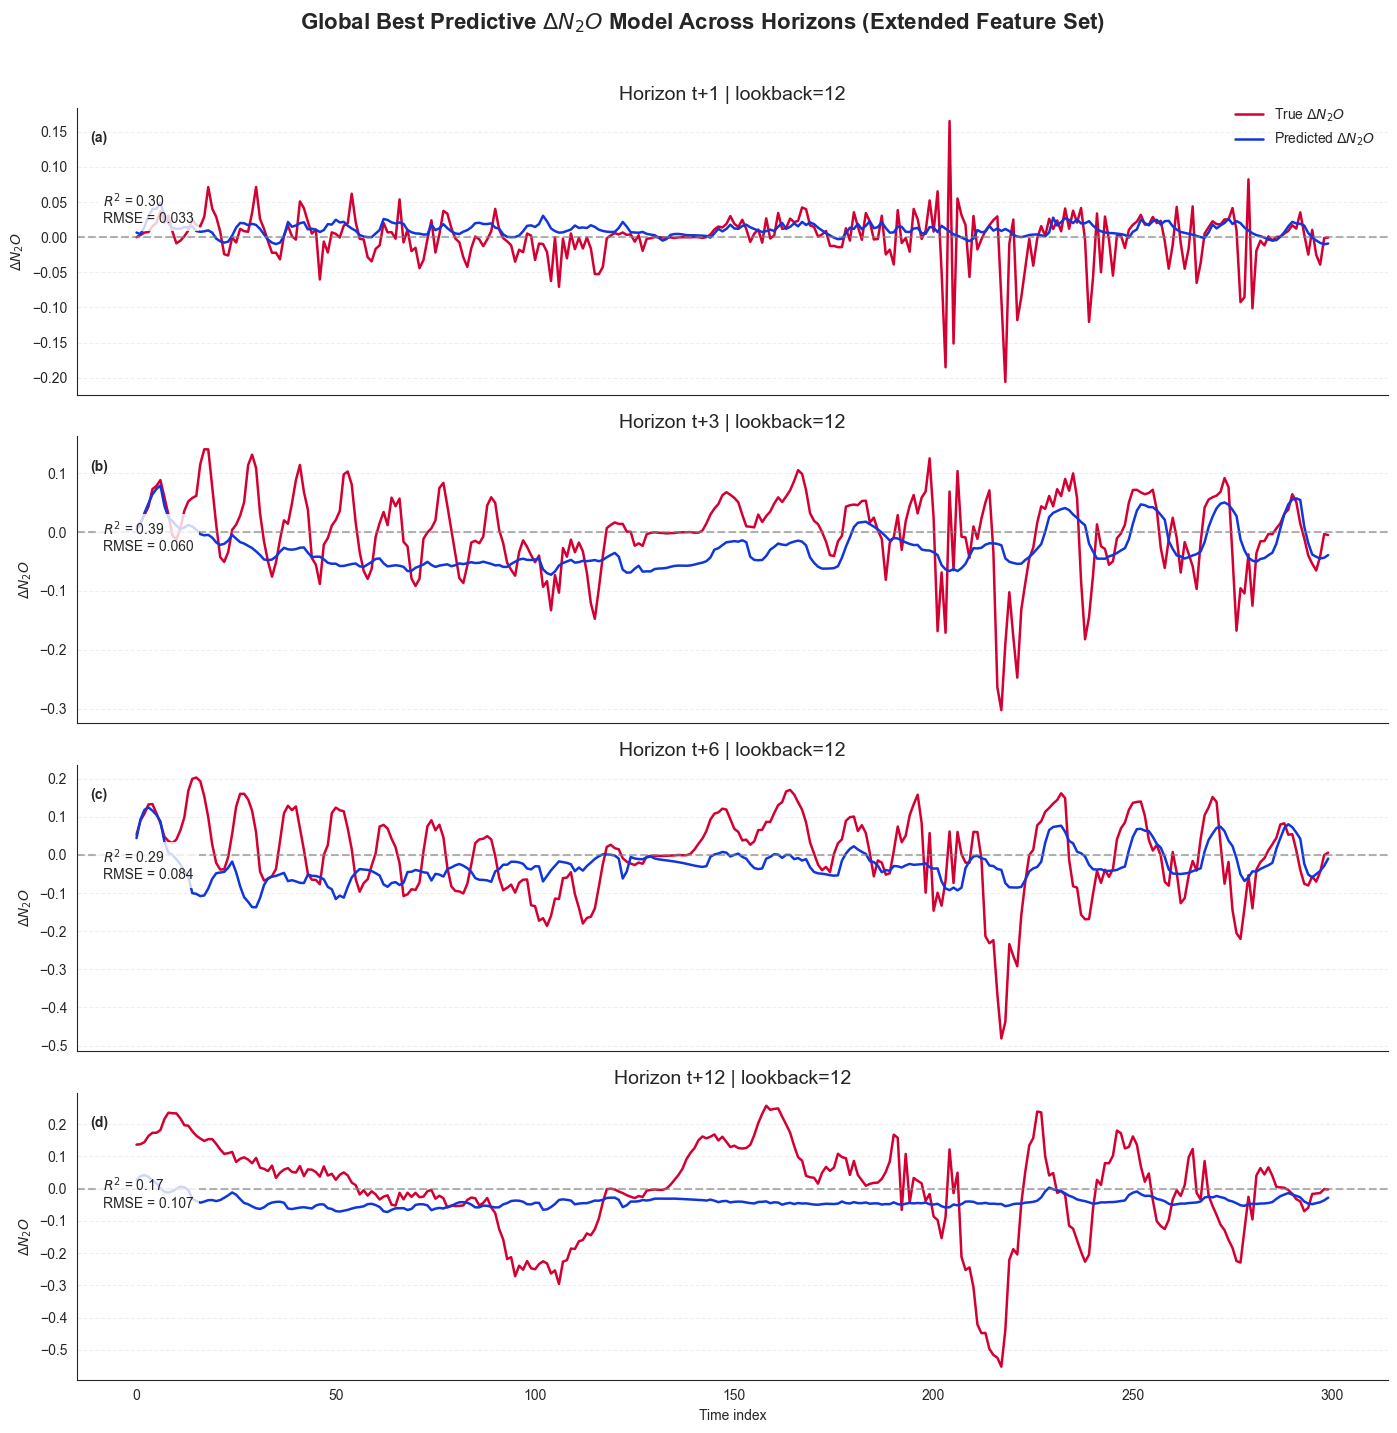

In [72]:
plot_delta_across_horizons(
    best_models_overall=best_delta_global,
    model_dir="../../models/lstm_n2o"
)

**Notes:** 

- Model significantly underestimates variability in $N_2O$ levels, failing to capture both magnitude and direction of changes 

- Predictions are largely centred around zero  due to noisy data and small magnitude of target 

- Δ$N_2O$ exhibits weak temporal structure and low persistence, even with lagged inputs

- Transformation from absolute $N_2O$ to Δ$N_2O$ removes smooth, autocorrelated structure and creates a signal centered around zero

- Forecasting performance is weak across all horizons

#### 3.2.3  Plot Best Model for Absolute $N_2O$

##### Identify best model for plotting

In [64]:
#Identify best performing model overall 
best_row_abs = results_absolute.loc[
    results_absolute["rmse"].idxmin()
]

best_feature_abs = best_row_abs["feature_set"]
best_lookback_abs = int(best_row_abs["lookback"])

best_absolute_global = results_absolute[
    (results_absolute["feature_set"] == best_feature_abs) &
    (results_absolute["lookback"] == best_lookback_abs)
]

In [65]:
#Check data 
print(best_absolute_global[["feature_set", "lookback", "horizon", "rmse", "r2"]])

   feature_set  lookback  horizon      rmse        r2
16    extended        12        1  0.043036  0.910929
17    extended        12        3  0.073031  0.743290
18    extended        12        6  0.102050  0.498786
19    extended        12       12  0.116184  0.350655


##### Define function for plotting 

In [69]:
def plot_absolute_across_horizons(
    best_models_overall,
    model_dir,
    horizons=[1, 3, 6, 12],
    start=0,
    window=300,
    color_true="#D50032",
    color_pred="#E87722"
):

    sns.set_style("white")

    COLOR_TRUE = color_true
    COLOR_PRED = color_pred

    feature_set = best_models_overall["feature_set"].iloc[0]
    lb = int(best_models_overall["lookback"].iloc[0])

    print(f"Using feature_set={feature_set}, lookback={lb}")

    fig, axes = plt.subplots(len(horizons), 1, figsize=(14, 12), sharex=True)

    if len(horizons) == 1:
        axes = [axes]

    labels = list(string.ascii_lowercase)

    for i, h in enumerate(horizons):

        row = best_models_overall[best_models_overall["horizon"] == h]
        ax = axes[i]

        if row.empty:
            ax.set_title(f"h={h} (missing)")
            continue

        r2 = float(row["r2"].values[0])
        rmse = float(row["rmse"].values[0])

        prefix = f"absolute_{feature_set}_lb{lb}_h{h}"

        pred_path = f"{model_dir}/{prefix}_y_pred.npy"
        true_path = f"{model_dir}/{prefix}_y_true.npy"

        if not os.path.exists(pred_path):
            ax.set_title(f"h={h} (missing)")
            print(f"Missing: {pred_path}")
            continue

        y_pred = np.load(pred_path).flatten()
        y_true = np.load(true_path).flatten()

        end = min(start + window, len(y_true))

        y_true_plot = y_true[start:end]
        y_pred_plot = y_pred[start:end]

        ax.plot(y_true_plot, label="True $N_2O$", color=COLOR_TRUE, linewidth=1.8)
        ax.plot(y_pred_plot, label="Predicted $N_2O$", color=COLOR_PRED, linewidth=1.8)

        ax.text(0.01, 0.88, f"({labels[i]})", transform=ax.transAxes, fontweight="bold")

        ax.text(
            0.02, 0.60,
            f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

        ax.set_title(f"Horizon t+{h} | lookback={lb}", fontsize=14)
        ax.set_ylabel("$N_2O$")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        if i == 0:
            ax.legend(frameon=False)

    axes[-1].set_xlabel("Time index")

    sns.despine()

    fig.suptitle(
        "Global Best Predictive Model for Absolute $N_2O$ Concentration Across Horizons (Extended Feature Set)",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    
    plt.show()

##### Plot true vs. predicted 

Using feature_set=extended, lookback=12


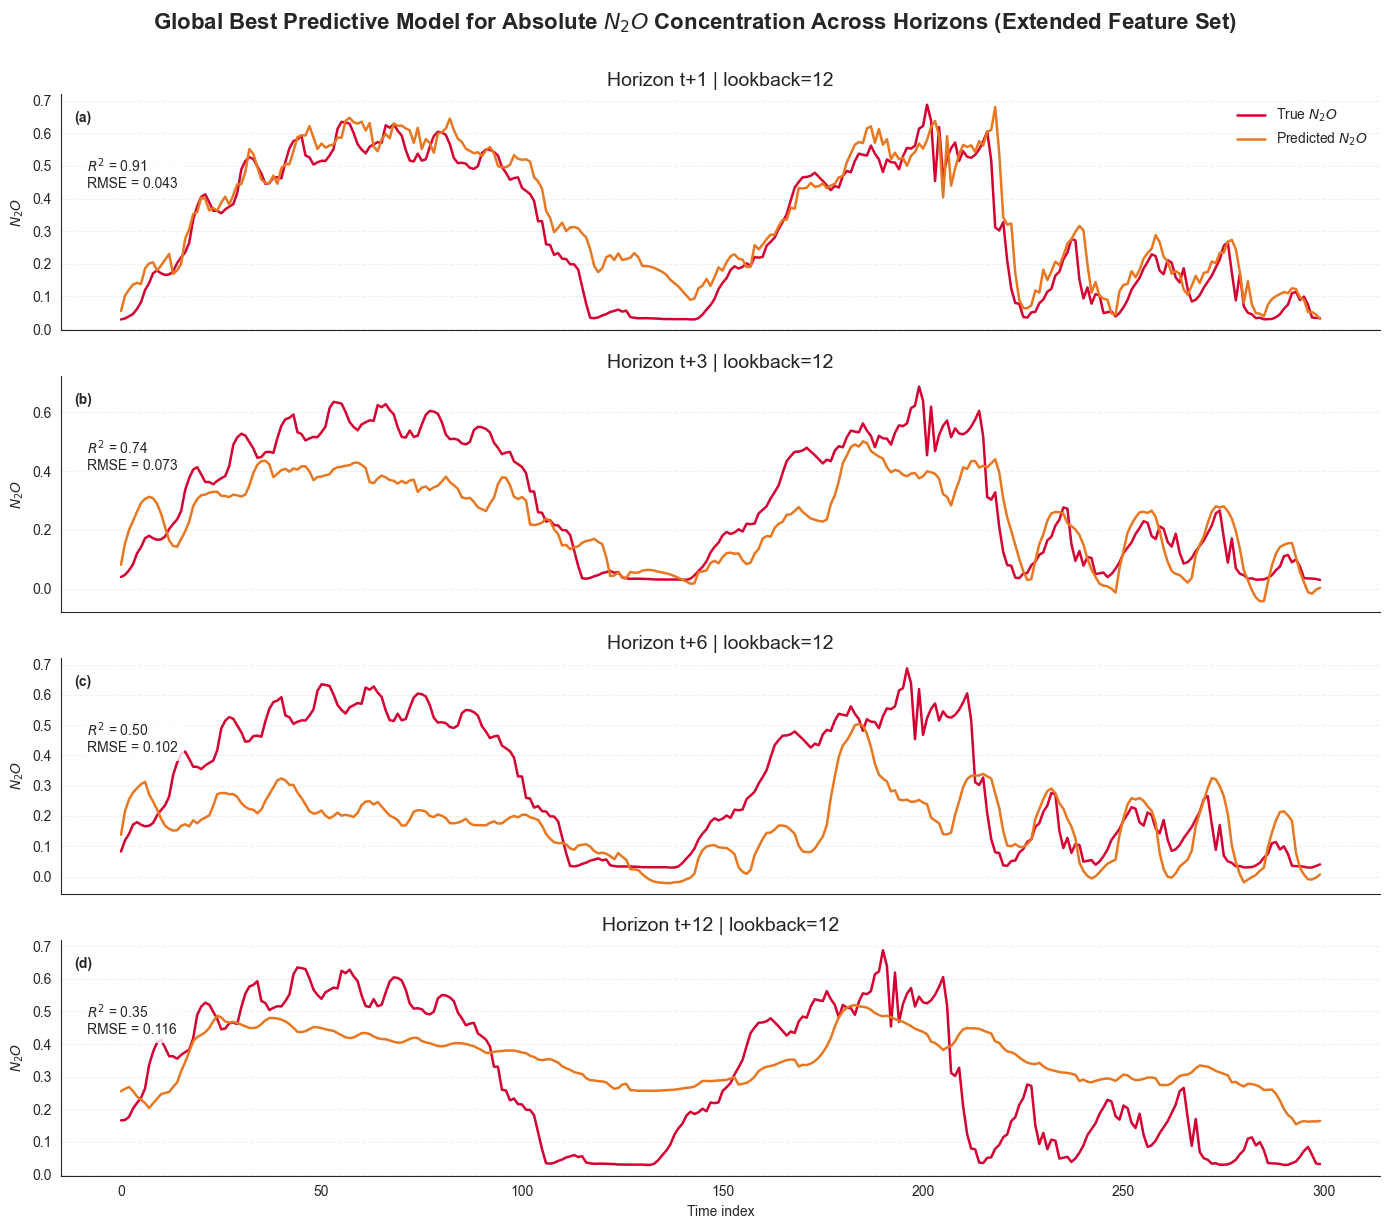

In [70]:
plot_absolute_across_horizons(
    best_models_overall=best_absolute_global,
    model_dir="../../models/lstm_n2o_absolute",
)

**Notes:** 

- The model has strong performance for short-term forecasting (10 min ahead), with an R2 value equal to 0.91 and RMSE of 0.043. The model is able to capture most peaks accurately (magnitude and direction)

- Forecasting accuracy declines as forecast horizon increases, at 30 min forecasting horizon, the model is still able to detect most peak events, but underestimates magnitude for most extreme ones especially. 

- For models forecasting 1 hour and 2 hours ahead, the model consistently underestimates peaks and no longer captures variability in $N_2O$ concentrations. This potentially indicates reduced temporal dependence across long horizons.

### 3.3 Peak Prediction Metrics 

To evaluate the ability of the model forecasting absolute N2O emissions to detect high-emissions events, we calculate a set of peak prediction metrics on the best performing model.

The metrics calculated include: 

- Precision (accuracy of predicted peaks)
- Recall (ability to detect true peaks)
- F1-score (balance between precision and recall)  


#### 3.3.1 Identify Best Model 

We identify the best model globally to evaluate peak prediction for a single model. At this stage, only one model was evaluated to focus on the most operationally relevant model, as well as due to time constraints.

See the above section for the best overall model. 

In [68]:
feature_cols = feature_sets[best_feature_abs]

print("Using feature set:", best_feature_abs)
print("Lookback:", best_lookback_abs)
print("Features:", feature_cols)

Using feature set: extended
Lookback: 12
Features: ['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min']


**Best model (global):** 

- Lookback window: 12 steps
- Feature set: extended feature set 

Then, select the all horizons for that configuration (same feature set + lookback) - although the selected configuration is optimal for the specific forecast horizon, it is used to evaluate across all horizons for consistency.

In [40]:
best_absolute_global = results_absolute[
    (results_absolute["feature_set"] == best_feature_abs) &
    (results_absolute["lookback"] == best_lookback_abs)
]

#### 3.3.2 Define function to evaluate peak metrics 

Next, we define a function to evaluate peak performance metrics for the selected model which: 

- Extracts the selected model configuration
- Iterates across all forecast horizons by loading the corresponding saved predictions (saved via the main training loop)
- Load predictions and true values (.npy files, y_pred and y_true)
- Convert regression outputs to classification problem by applying a 95th threhold define based on the 95th percentile of training data 
- Convert values into binary labels (1 = peak event; 0 = non-peak event)
- Compute classification metrics (precision, recall, F1 score)
- Store results including metrics for each forecast horizon

In [43]:
def evaluate_peak_metrics(
    best_models,
    model_dir,
    threshold,
    target_mode="absolute",
    horizons=[1,3,6,12]
):
    results = []

    feature_set = best_models["feature_set"].iloc[0]
    lb = int(best_models["lookback"].iloc[0])

    print(f"\nEvaluating {target_mode} peaks | feature={feature_set}, lb={lb}")

    for h in horizons:

        prefix = f"{target_mode}_{feature_set}_lb{lb}_h{h}"

        pred_path = f"{model_dir}/{prefix}_y_pred.npy"
        true_path = f"{model_dir}/{prefix}_y_true.npy"

        if not os.path.exists(pred_path):
            print("Missing:", prefix)
            continue

        y_pred = np.load(pred_path).flatten()
        y_true = np.load(true_path).flatten()

        y_true_peaks = (y_true >= threshold).astype(int)
        y_pred_peaks = (y_pred >= threshold).astype(int)

        precision = precision_score(y_true_peaks, y_pred_peaks, zero_division=0)
        recall    = recall_score(y_true_peaks, y_pred_peaks, zero_division=0)
        f1        = f1_score(y_true_peaks, y_pred_peaks, zero_division=0)

        results.append({
            "target": target_mode,
            "horizon": h,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(results)

#### 3.3.3 Define 95th Percentile Threshold

To evaluate peak prediction performance, we define a threshold to identify preak events in $N_2O$ concentrations. 

This is done by reconstructing the training targets and calculating a threshold value using the 95th percentile of the training target distribution. This is calculated using the training data only to avoid data leakage and to evaluate model performance fairly (learning based on peak events defined during training).

In [54]:
#Recreate training data for best absolute model to analyze predictions in detail
X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_and_split_segments_absolute(
    segments=segments,
    feature_cols=feature_cols,
    feature_name=best_feature_abs,
    horizons=[1,3,6,12],
    seq_length=best_lookback_abs
)


[debug] extended feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min', 't1_n2o']

[debug] extended feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min', 't1_n2o']

[debug] extended feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min', 't1_n2o']

[debug] extended feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 'phase_change', 'is_anoxic', 't1_do_std_30min', 'do_error_std_30min', 't1_n2o']

[debug] extended feature columns:
['t1_nh4', 't1_no3', 't1_airflow', 't1_temp', 't1_po4', 'inflow', 't1_do', 'do_error', 'is_aerated', 

In [ ]:
#Concatenate training data for all horizons to get full range of true values
y_train_all = np.concatenate(y_train)

#Define peak threshold as 95th percentile of training target values
threshold = np.percentile(y_train_all, 95)

#Print threshold for reference
print(f"Training threshold: {threshold:.4f}")

Training threshold: 0.4463


#### 3.3.4 Evaluate Peak Performance

In [130]:
peak_absolute = evaluate_peak_metrics(
    best_models=best_absolute_global,
    model_dir="../models/lstm_n2o_absolute",
    threshold=threshold,
    target_mode="absolute"
)


Evaluating absolute peaks | feature=extended, lb=12


In [131]:
print(peak_absolute)

     target  horizon  precision    recall        f1
0  absolute        1   0.882075  0.877934  0.880000
1  absolute        3   0.693182  0.286385  0.405316
2  absolute        6   0.746479  0.248826  0.373239
3  absolute       12   0.639098  0.399061  0.491329


#### 3.3.5 Save to CSV 

In [ ]:
peak_absolute.to_csv("../../data/lstm_data/figures/peak_metrics_absolute.csv", index=False)

#### 3.3.6 Evaluate Peak Performance 

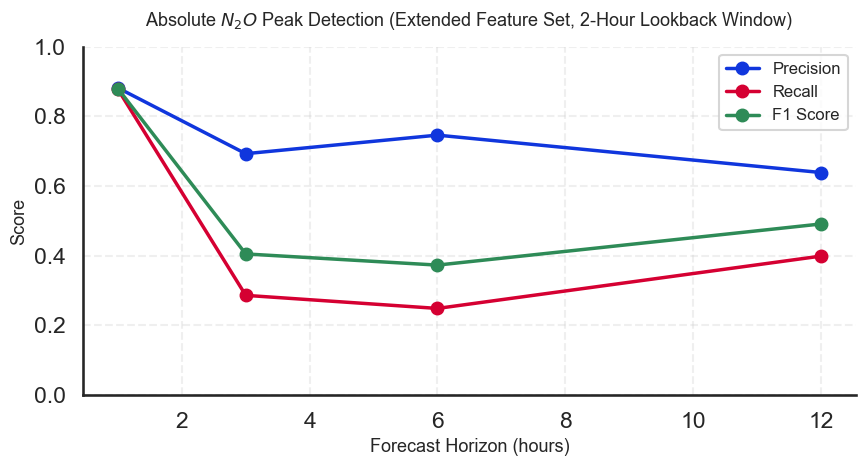

In [ ]:
sns.set_theme(style="white", context="talk")
df = peak_absolute.sort_values("horizon")

#Define colors for plotting metrics 
COLOR_PREC = "#1036DD"  
COLOR_REC  = "#D50032"
COLOR_F1   = "#2E8B57"

plt.figure(figsize=(9, 5))

plt.plot(df["horizon"], df["precision"],
         marker="o", linewidth=2.5, color=COLOR_PREC, label="Precision")

plt.plot(df["horizon"], df["recall"],
         marker="o", linewidth=2.5, color=COLOR_REC, label="Recall")

plt.plot(df["horizon"], df["f1"],
         marker="o", linewidth=2.5, color=COLOR_F1, label="F1 Score")

plt.xlabel("Forecast Horizon")
plt.ylabel("Score")

plt.title("Absolute $N_2O$ Peak Detection (Extended Feature Set, 2-Hour Lookback Window)", fontsize=13, pad=15)

plt.xlabel("Forecast Horizon (hours)", fontsize=13)
plt.ylabel("Score", fontsize=13)

plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(frameon=True, fontsize=12)

sns.despine()

plt.tight_layout()

plt.show() 

### AI Usa Disclaimer

This work was completed with the support of AI-based tools. ChatGPT was used to assist with  code structuring and debugging, while GitHub Copilot provided code completion suggestions. All generated content has been critically evaluated, modified where necessary, and verified by the author to ensure accuracy and academic integrity.